# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [65]:
import pandas as pd


df = pd.read_csv('/content/athlete_events.csv')

print(f"El dataframe tiene {df.shape[0]} filas y {df.shape[1]} columnas.\n")

df.info()
df.head()

El dataframe tiene 271116 filas y 15 columnas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [66]:
df['Medal'] = df['Medal'].fillna('No medal')

In [67]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [69]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No medal
2,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No medal
3,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",No medal
4,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,No medal


In [70]:
df.describe()

,ID,Age,Height,Weight,Year
count,206152.000000,206152.000000,206152.000000,206152.000000,206152.00000
mean,68615.742981,25.054736,175.372056,70.688332,1989.67849
std,38996.980304,5.481679,10.545816,14.340633,20.12571
min,1.000000,11.000000,127.000000,25.000000,1896.00000
25%,35189.000000,21.000000,168.000000,60.000000,1976.00000
50%,68629.000000,24.000000,175.000000,70.000000,1992.00000
75%,102312.250000,28.000000,183.000000,79.000000,2006.00000
max,135571.000000,71.000000,226.000000,214.000000,2016.00000


In [71]:
df.describe(include='object').T

,count,unique,top,freq
Name,206152,98546,Heikki Ilmari Savolainen,39
Sex,206152,2,M,139441
Team,206152,660,United States,13707
NOC,206152,226,USA,14207
Games,206152,51,2000 Summer,13682
Season,206152,2,Summer,166693
City,206152,42,London,13803
Sport,206152,56,Athletics,32374
Event,206152,590,Ice Hockey Men's Ice Hockey,3825
Medal,206152,4,No medal,175971


In [72]:
# Revisamos cuántos valores únicos tiene cada columna, para detectar
# claves primarias, variables constantes y variables redundantes
for col in df.columns:
    print(f"{col}: {df[col].nunique()} valores únicos")

ID: 99088 valores únicos
Name: 98546 valores únicos
Sex: 2 valores únicos
Age: 61 valores únicos
Height: 94 valores únicos
Weight: 217 valores únicos
Team: 660 valores únicos
NOC: 226 valores únicos
Games: 51 valores únicos
Year: 35 valores únicos
Season: 2 valores únicos
City: 42 valores únicos
Sport: 56 valores únicos
Event: 590 valores únicos
Medal: 4 valores únicos


**RESPUESTA**

Se cuenta inicialmente con 271,116 filas y 15 columnas. Aqui se encuentran: dtypes: float64(3), int64(2), object(10)

**Clave primaria**

ID: Es el identificador único de cada atleta

Name: Nombre completo del atleta (identificador único)

**Valores únicos**

Ninguna variable del dataset es constante (todas tienen al menos 2 valores únicos)

**Redundantes entre sí**

NOC y Team: NOC es la versión codificada estandarizada de tres letras del país/equipo (Team), por lo que representan la misma información geográfica/nacional.  

Games: Es redundante porque se compone exactamente de la unión de las variables Year y Season (ej. "1992 Summer").  

City: Está fuertemente ligada a Games / Year / Season, ya que cada edición olímpica ocurrió en una ciudad específica.

**Riesgo de filtración de datos (data leakage)**

Medal: La consecución o el tipo de medalla se conoce únicamente después de finalizada la competencia (además, no debería ser determinante para predecir la condición física/peso previa del atleta)


**Descarte de variables**

In [73]:
columnas_a_descartar = [
    'ID', 'Name',      # Claves primarias
    'Team',            # Redundante
    'Games', 'City',   # Redundantes con Year y Season
    'Medal'            # Riesgo de filtración
]

df = df.drop(columns=columnas_a_descartar)

print(f"El dataframe quedó con {df.shape[1]} columnas.\n")
df.info()

El dataframe quedó con 9 columnas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206152 entries, 0 to 206151
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     206152 non-null  object 
 1   Age     206152 non-null  float64
 2   Height  206152 non-null  float64
 3   Weight  206152 non-null  float64
 4   NOC     206152 non-null  object 
 5   Year    206152 non-null  int64  
 6   Season  206152 non-null  object 
 7   Sport   206152 non-null  object 
 8   Event   206152 non-null  object 
dtypes: float64(3), int64(1), object(5)
memory usage: 14.2+ MB


---------------------------------------------------------------------



Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.

In [21]:
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index(['Sex', 'NOC', 'Season', 'Sport', 'Event'], dtype='object')


In [22]:
for col in cat_cols:
    print(f'\n--- {col} ---')
    print(df[col].unique())
    print(f'Cardinalidad: {df[col].nunique()}')


--- Sex ---
['M' 'F']
Cardinalidad: 2

--- NOC ---
['CHN' 'DEN' 'NED' 'USA' 'FIN' 'NOR' 'ROU' 'EST' 'FRA' 'MAR' 'ESP' 'EGY'
 'IRI' 'BUL' 'ITA' 'CHA' 'AZE' 'SUD' 'RUS' 'ARG' 'CUB' 'BLR' 'GRE' 'CMR'
 'TUR' 'CHI' 'MEX' 'URS' 'NCA' 'HUN' 'NGR' 'ALG' 'KUW' 'BRN' 'PAK' 'IRQ'
 'UAR' 'LIB' 'QAT' 'MAS' 'GER' 'CAN' 'IRL' 'AUS' 'RSA' 'ERI' 'TAN' 'JOR'
 'TUN' 'LBA' 'BEL' 'DJI' 'PLE' 'COM' 'KAZ' 'BRU' 'IND' 'KSA' 'SYR' 'MDV'
 'ETH' 'UAE' 'YAR' 'INA' 'PHI' 'SGP' 'UZB' 'KGZ' 'TJK' 'EUN' 'JPN' 'CGO'
 'SUI' 'BRA' 'FRG' 'GDR' 'MON' 'ISR' 'URU' 'SWE' 'ISV' 'SRI' 'ARM' 'CIV'
 'KEN' 'BEN' 'UKR' 'GBR' 'GHA' 'SOM' 'LAT' 'NIG' 'MLI' 'AFG' 'POL' 'CRC'
 'PAN' 'GEO' 'SLO' 'CRO' 'GUY' 'NZL' 'POR' 'PAR' 'ANG' 'VEN' 'COL' 'BAN'
 'PER' 'ESA' 'PUR' 'UGA' 'HON' 'ECU' 'TKM' 'MRI' 'SEY' 'TCH' 'LUX' 'MTN'
 'CZE' 'SKN' 'TTO' 'DOM' 'VIN' 'JAM' 'LBR' 'SUR' 'NEP' 'MGL' 'AUT' 'PLW'
 'LTU' 'TOG' 'NAM' 'AHO' 'ISL' 'ASA' 'SAM' 'RWA' 'DMA' 'HAI' 'MLT' 'CYP'
 'GUI' 'BIZ' 'YMD' 'KOR' 'THA' 'BER' 'ANZ' 'SCG' 'SLE' 'PNG' 'YEM' 'IOA'

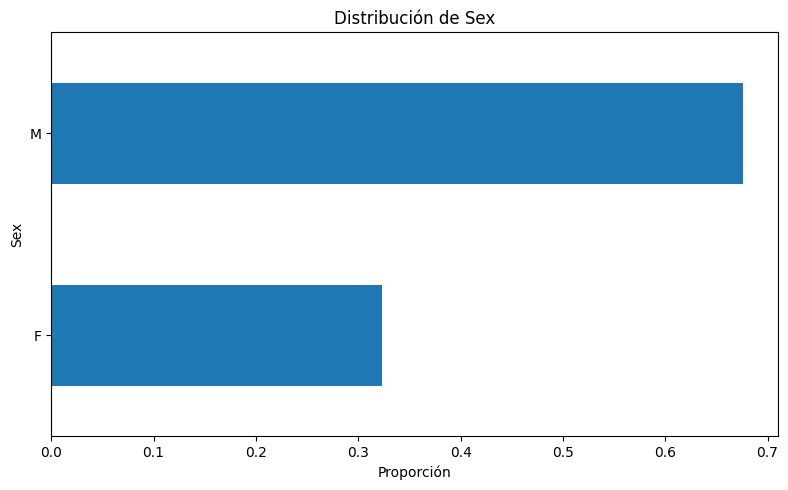

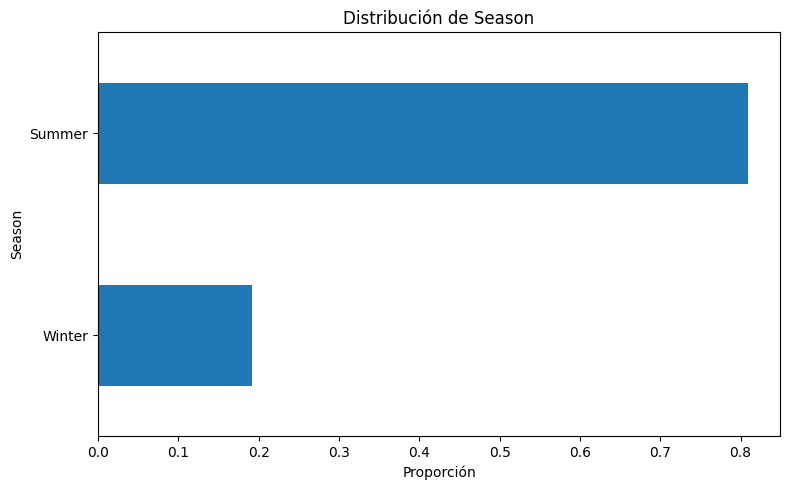

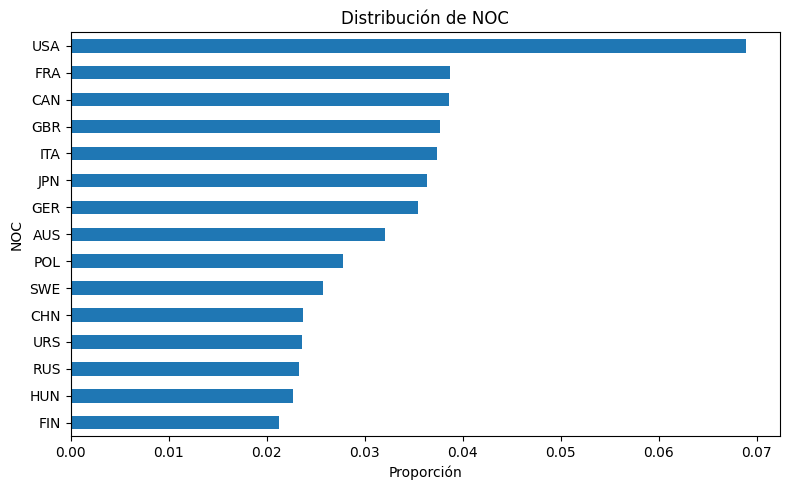

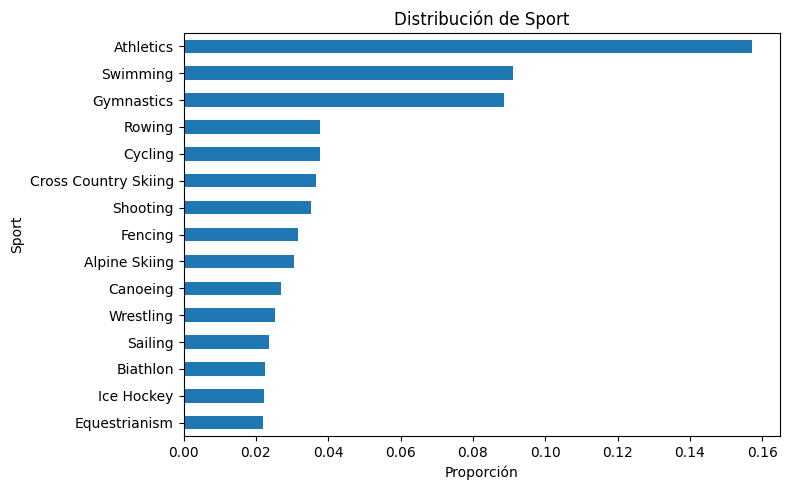

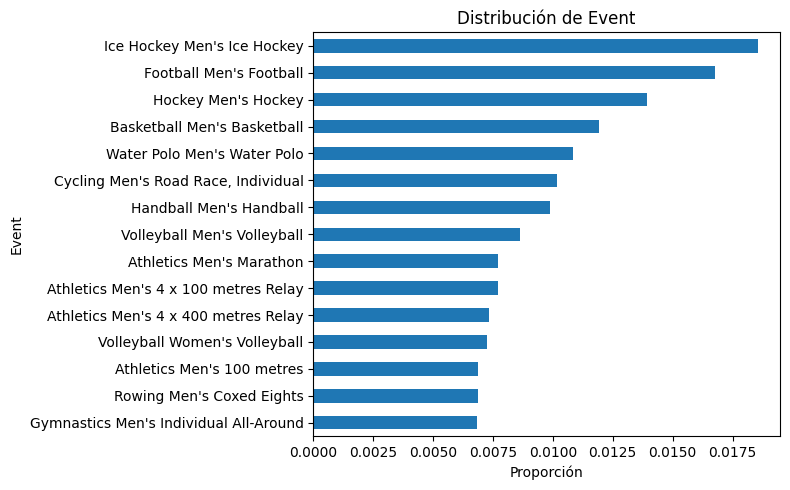

In [96]:
import matplotlib.pyplot as plt

# Variables categóricas no descartadas
cat_vars = ['Sex', 'Season', 'NOC', 'Sport', 'Event']

for var in cat_vars:
    plt.figure(figsize=(8, 5))


    df[var].value_counts(normalize=True).head(15).plot(kind='barh')

    plt.title(f'Distribución de {var}')
    plt.xlabel('Proporción')
    plt.ylabel(var)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

**Variables nominales (no tienen un orden natural entre sus categorías):**

Sex, Season, NOC, Sport y Event. Ninguna de estas variables presenta una jerarquía entre sus opciones.

**Variables ordinales (sí tienen un orden lógico):**

Ninguna de las variables categóricas restantes posee un orden jerárquico implícito. (La única variable que se podia considerar del conjunto de datos original era Medal, pero fue descartada en la etapa anterior por representar un riesgo de filtración de datos —data leakage—).

 **Variables con alta cardinalidad:**

 Event, NOC y Sport. La variable Event posee una cardinalidad extremadamente alta con 765 valores únicos. Le sigue NOC con 230 comités olímpicos distintos y Sport con 66 disciplinas diferentes.
 Por el contrario, las variables Sex y Season presentan una baja cardinalidad con solo 2 categorías cada una.  

 **Variables con categorías atípicas:**

Event, NOC y Sport. Tienen categorías muy poco frecuentes en el dataset (como deportes extintos, delegaciones históricas o pruebas descontinuadas): Event tiene 76 pruebas con menos de 10 apariciones, NOC incluye 8 delegaciones con registros muy bajos y Sport cuenta con 3 deportes atípicos (como Aeronautics).


**Procesamiento sugerido**

* OneHotEncoder
Tipo de variable: Sex y Season.  

* TargetEncoder
Tipo de variable:  NOC, Sport y Event.

--------------------------------------------------------

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

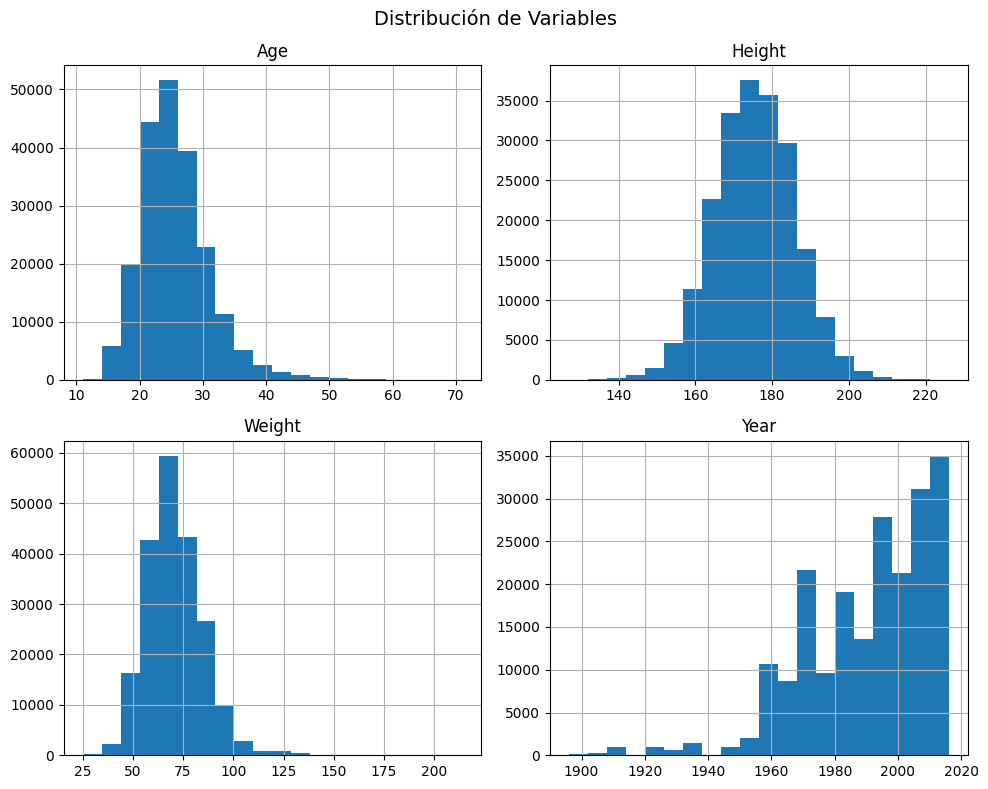

In [97]:
import matplotlib.pyplot as plt


num_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

df[num_vars].hist(figsize=(10, 8), bins=20)
plt.suptitle('Distribución de Variables', fontsize=14)
plt.tight_layout()
plt.show()



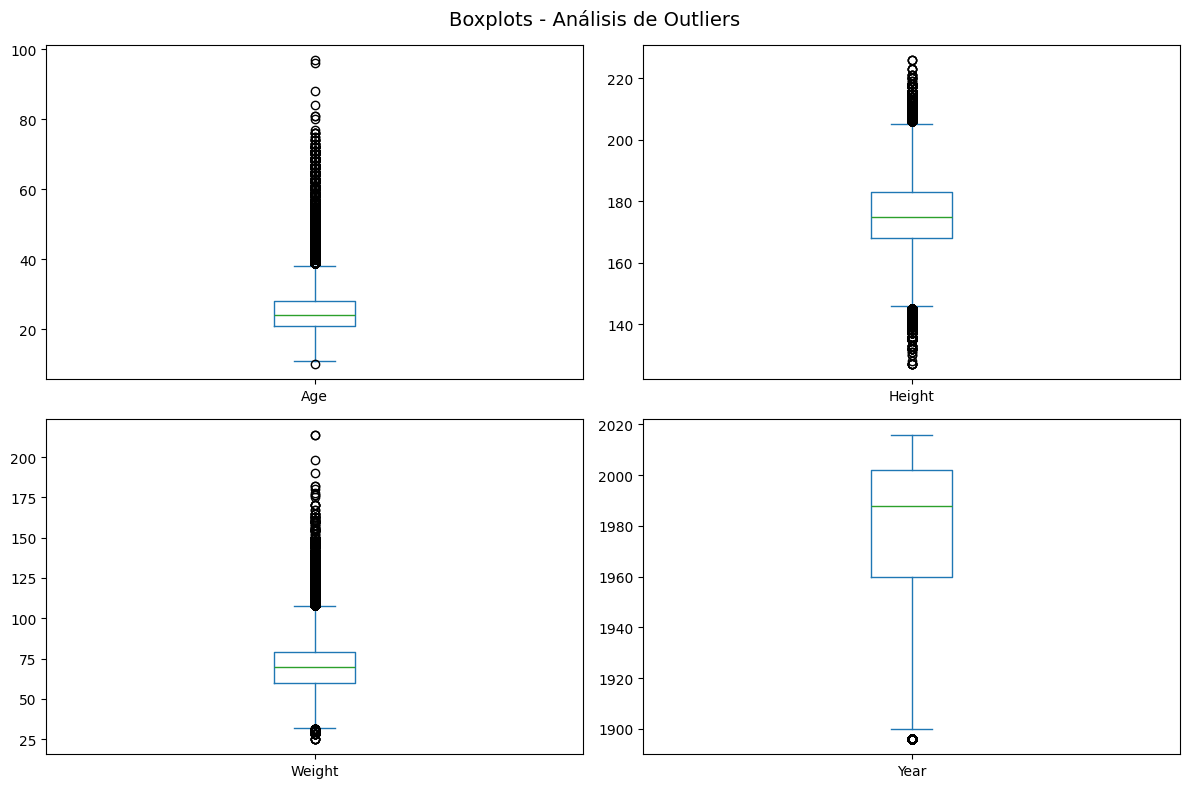

In [31]:
# Boxplots - Análisis de Outliers
df[num_vars].plot(
    kind='box',
    figsize=(12, 8),
    subplots=True,
    layout=(2, 2),
    sharex=False,
    sharey=False
)
plt.suptitle('Boxplots - Análisis de Outliers', fontsize=14)
plt.tight_layout()
plt.show()

**Variables que son aproximadamente normales:**

* Height (Estatura): Presenta una distribución simétrica casi perfecta centrándose alrededor de los 175 cm.

* Weight (Variable Objetivo): Aunque tiene un ligero sesgo hacia la izquierda por atletas de disciplinas pesadas, sigue una distribución acampanada bastante bien definida.

**Variables con datos atípicos**

* Age (Edad): Presenta una gran cantidad de datos atípicos severos en la parte superior del gráfico (edades mayores a 38 años hasta el máximo de 97 años). Esto ocurre por atletas veteranos en disciplinas específicas como arte o tiro deportivo.  

* Height (Estatura): Contiene valores atípicos en ambos extremos (alturas muy bajas y valores muy altos).  

* Weight (Peso): Muestra una cantidad significativa de outliers superiores(asociados a levantamiento de pesas o judo).  

* Year (Año): No presenta valores atípicos severos, excepto los primeros años olímpicos que se marcan como valores extremos al borde del bigote inferior

**Procesamiento suguerido:**

* StandardScaler
Tipo de variable:  Height (Estatura).

* PowerTransformer
Tipo de variable:  Age (Edad) y Weight (Variable Objetivo).

* MinMaxScaler
Tipo de varible: Year (Año)

------------------------------------------------------------------------------------------


Haga análisis bivariados entre las variables de su dataset y la variable objetivo, e identifique que variables serían potencialmente buenas predictoras y cuales no.

Reporte sus resultados en una celda de texto.

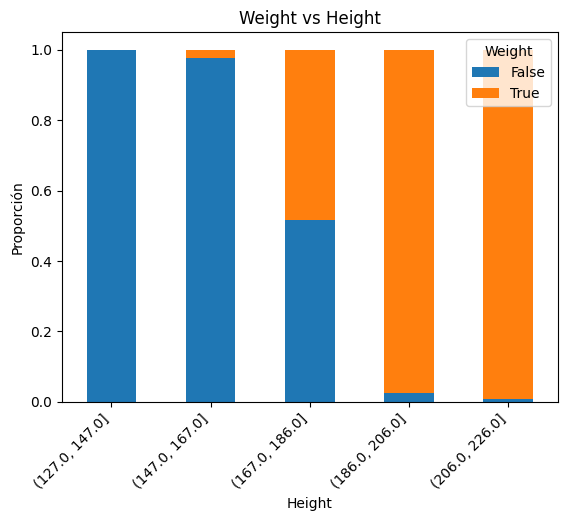

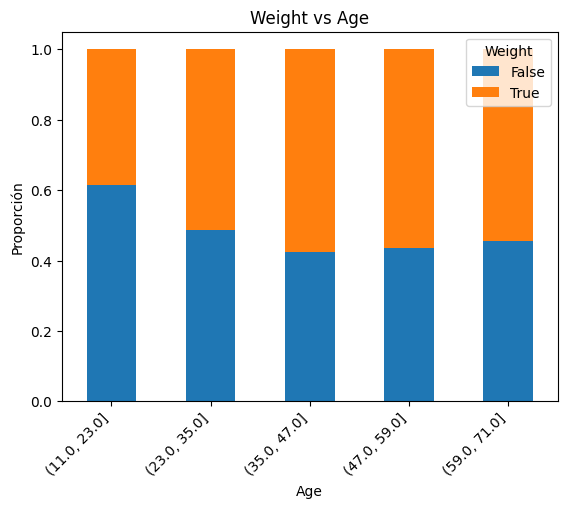

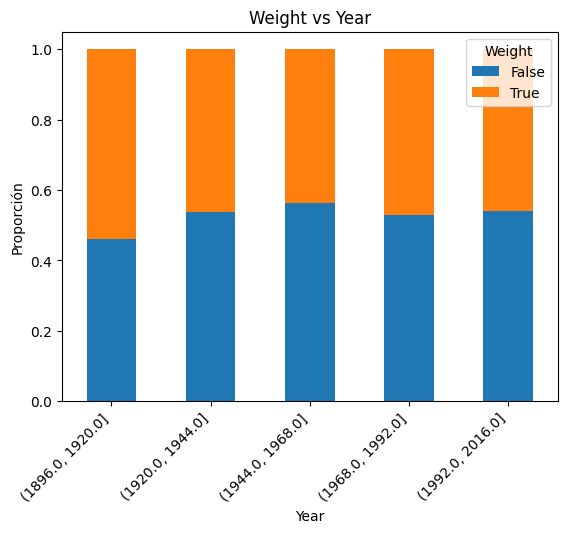

In [84]:
# Cuantitativas vs Weight
import matplotlib.pyplot as plt
import pandas as pd

num_vars = ["Height", "Age", "Year"]

for var in num_vars:
    var_corta = pd.cut(df[var], bins=5, precision=0)

    tabla = pd.crosstab(
        var_corta, df["Weight"] > df["Weight"].median(), normalize="index"
    )
    ax = tabla.plot.bar(stacked=True)
    plt.title(f"Weight vs {var}")
    plt.ylabel("Proporción")
    plt.xticks(rotation=45, ha="right")
    plt.show()

Height: Presenta una relación directa extremadamente clara. A mayor estatura, la proporción de atletas por encima de la mediana de peso se incrementa drásticamente. Es una excelente variable predictora.

Age: Muestra una variación moderada. Aunque los atletas maduros tienden a registrar pesos ligeramente mayores en comparación con los muy jóvenes, la diferencia en la distribución no es tan marcada en la mayoría de rangos. Es una variable predictora moderada o regular.

Year: No muestra cambios significativos. La distribución del peso en relación con la mediana se mantiene casi constante a lo largo de las distintas ediciones. Es una mala variable predictora.

<Figure size 640x480 with 0 Axes>

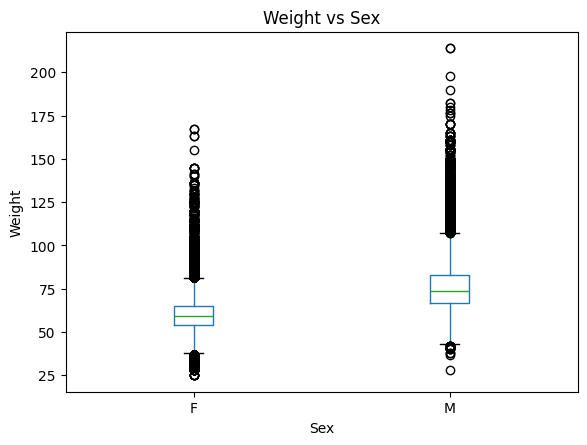

<Figure size 640x480 with 0 Axes>

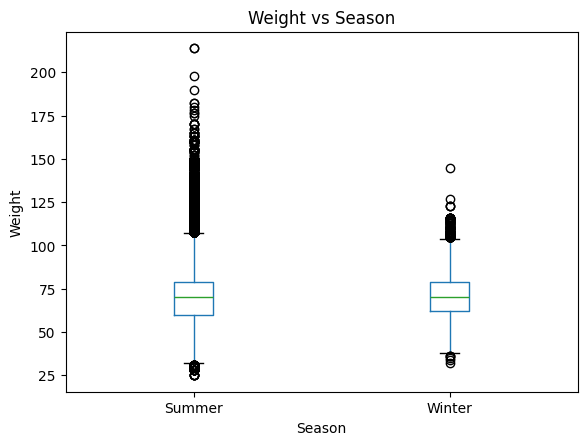

<Figure size 640x480 with 0 Axes>

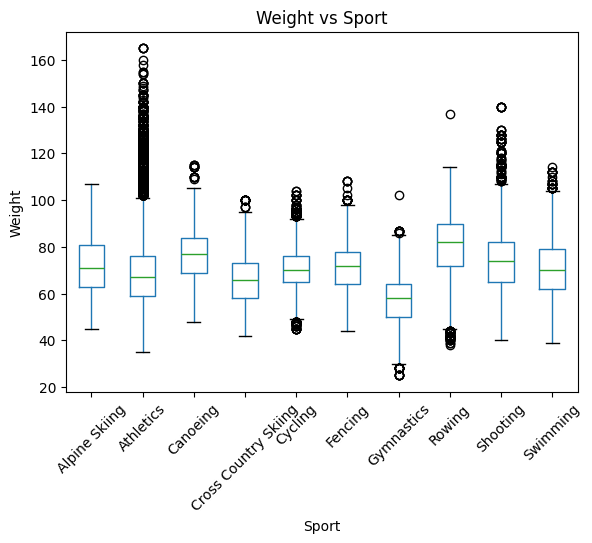

In [83]:
# Cualitativas vs Weight
import matplotlib.pyplot as plt

cat_vars = ['Sex', 'Season', 'Sport']

for var in cat_vars:
    plt.figure()

    if var == 'Sport':
        top_sports = df['Sport'].value_counts().head(10).index
        df[df['Sport'].isin(top_sports)].boxplot(column="Weight", by=var, grid=False, vert=True)
        plt.xticks(rotation=45)
    else:
        df.boxplot(column="Weight", by=var, grid=False, vert=True)

    plt.title(f'Weight vs {var}')
    plt.suptitle('')
    plt.ylabel('Weight')
    plt.show()

Sex: Presenta una diferencia muy marcada. Los hombres tienen una mediana de peso significativamente mayor que las mujeres. Es una excelente variable predictora.

Sport: Muestra variaciones drásticas según el deporte. Disciplinas como Gimnasia tienen pesos muy bajos, mientras que Remo registra pesos muy altos.Es una excelente variable predictora.

Season: No muestra diferencias. La mediana de peso es exactamente la misma tanto en Summer como en Winter. Es una mala variable predictora.

-------------------------------------------------------------------------------------------

## Procesamiento de las características y entrenamiento del modelo

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Weight**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 5 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 5 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión lineal. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [85]:

from sklearn.model_selection import train_test_split

X = df.drop(columns=['Weight'])
y = df['Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.8)

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape}')
print(f'Tamaño del conjunto de prueba: {X_test.shape}')

Tamaño del conjunto de entrenamiento: (164921, 8)
Tamaño del conjunto de prueba: (41231, 8)


In [89]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

ss = StandardScaler()

ohe = OneHotEncoder(sparse_output=False, drop='if_binary', handle_unknown='ignore')

preprocessor = ColumnTransformer(transformers=[
    ('numericas', ss, ['Height', 'Age']),
    ('nominales', ohe, ['Sex', 'Season', 'Sport'])
    ],
    remainder='drop')

preprocessor

ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                 ['Height', 'Age']),
                                ('nominales',
                                 OneHotEncoder(drop='if_binary',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Sex', 'Season', 'Sport'])])

In [90]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
    ])

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                                  ['Height', 'Age']),
                                                 ('nominales',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Sex', 'Season',
                                                   'Sport'])])),
                ('model', LinearRegression())])

In [91]:
pipeline.fit(X_train, y_train)

print(f'Score (R^2) en entrenamiento: {pipeline.score(X_train, y_train):.4f}')
print(f'Score (R^2) en prueba: {pipeline.score(X_test, y_test):.4f}')

feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

print(f'\nNúmero total de características resultantes: {len(feature_names)}')
print('Características procesadas utilizadas en el entrenamiento:')
for name in feature_names:
    print(f'- {name}')

Score (R^2) en entrenamiento: 0.7298
Score (R^2) en prueba: 0.7324

Número total de características resultantes: 60
Características procesadas utilizadas en el entrenamiento:
- numericas__Height
- numericas__Age
- nominales__Sex_M
- nominales__Season_Winter
- nominales__Sport_Alpine Skiing
- nominales__Sport_Archery
- nominales__Sport_Art Competitions
- nominales__Sport_Athletics
- nominales__Sport_Badminton
- nominales__Sport_Baseball
- nominales__Sport_Basketball
- nominales__Sport_Beach Volleyball
- nominales__Sport_Biathlon
- nominales__Sport_Bobsleigh
- nominales__Sport_Boxing
- nominales__Sport_Canoeing
- nominales__Sport_Cross Country Skiing
- nominales__Sport_Curling
- nominales__Sport_Cycling
- nominales__Sport_Diving
- nominales__Sport_Equestrianism
- nominales__Sport_Fencing
- nominales__Sport_Figure Skating
- nominales__Sport_Football
- nominales__Sport_Freestyle Skiing
- nominales__Sport_Golf
- nominales__Sport_Gymnastics
- nominales__Sport_Handball
- nominales__Sport_Hock

Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [94]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

features_v2 = ['Height', 'Age', 'Year', 'Sex', 'Season', 'Sport']

print("Características V2:", features_v2)
print("Cantidad de características:", len(features_v2))

numeric_v2 = ['Height', 'Age', 'Year']
categorical_nominal_v2 = ['Sex', 'Season', 'Sport']

preprocessor_v2 = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), numeric_v2),
        ('nominal', OneHotEncoder(handle_unknown='ignore'), categorical_nominal_v2)
    ],
    remainder='drop')

modelo_v2 = Pipeline(steps=[('preprocessor', preprocessor_v2), ('regressor', LinearRegression())])
modelo_v2.fit(X_train[features_v2], y_train)

score_train_v2 = modelo_v2.score(X_train[features_v2], y_train)
score_test_v2 = modelo_v2.score(X_test[features_v2], y_test)

print("\nRESULTADOS V2")
print(f"Score entrenamiento: {score_train_v2:.4f}")
print(f"Score prueba: {score_test_v2:.4f}")

feature_names_v2 = modelo_v2.named_steps['preprocessor'].get_feature_names_out()

print("\nCaracterísticas después del preprocesamiento:")
for feature in feature_names_v2:
    print(feature)

print("\nCantidad de características transformadas:", len(feature_names_v2))

Características V2: ['Height', 'Age', 'Year', 'Sex', 'Season', 'Sport']
Cantidad de características: 6

RESULTADOS V2
Score entrenamiento: 0.7298
Score prueba: 0.7324

Características después del preprocesamiento:
numeric__Height
numeric__Age
numeric__Year
nominal__Sex_F
nominal__Sex_M
nominal__Season_Summer
nominal__Season_Winter
nominal__Sport_Alpine Skiing
nominal__Sport_Archery
nominal__Sport_Art Competitions
nominal__Sport_Athletics
nominal__Sport_Badminton
nominal__Sport_Baseball
nominal__Sport_Basketball
nominal__Sport_Beach Volleyball
nominal__Sport_Biathlon
nominal__Sport_Bobsleigh
nominal__Sport_Boxing
nominal__Sport_Canoeing
nominal__Sport_Cross Country Skiing
nominal__Sport_Curling
nominal__Sport_Cycling
nominal__Sport_Diving
nominal__Sport_Equestrianism
nominal__Sport_Fencing
nominal__Sport_Figure Skating
nominal__Sport_Football
nominal__Sport_Freestyle Skiing
nominal__Sport_Golf
nominal__Sport_Gymnastics
nominal__Sport_Handball
nominal__Sport_Hockey
nominal__Sport_Ice Hoc